In [19]:
import pandas as pd

# comparing (activity) feature of 4 csv files my_predictions.csv, hann_predictins.csv, my_predictions22.csv and my_predictions33.csv
df = pd.read_csv("../Predictions/my_prediction.csv")
df2 = pd.read_csv("../Predictions/hann_predictions.csv")
df3 = pd.read_csv("../Predictions/my_prediction22.csv")
df4 = pd.read_csv("../Predictions/my_prediction33.csv")
same = {"me_hann": 0, "me_me22": 0, "me_me33": 0}
diff = {"me_hann":0, "me_me22":0, "me_me33":0}
for i in range(len(df)):
    if df['activity'][i] == df2['Prediction'][i]:
        same['me_hann'] += 1
    else:
        diff['me_hann'] += 1
    if df['activity'][i] == df3['activity'][i]:
        same['me_me22'] += 1
    else:
        diff['me_me22'] += 1
    if df['activity'][i] == df4['activity'][i]:
        same['me_me33'] += 1
    else:
        diff['me_me33'] += 1



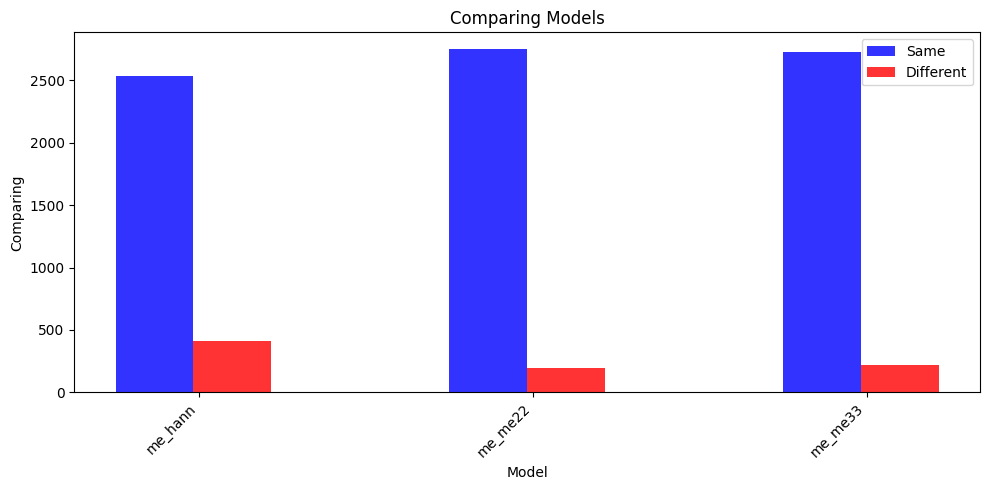

In [20]:
# plot the same and different
import matplotlib.pyplot as plt
import numpy as np

# data to plot
n_groups = 16
# same = [same['stack_DL'], same['stack_Model'], same['stack_xgb'], same['stack_rf'], same['stack_NN'], same['DL_Model'], same['DL_xgb'], same['DL_rf'], same['DL_NN'], same['Model_xgb'], same['Model_rf'], same['Model_NN'], same['xgb_rf'], same['xgb_NN'], same['rf_NN'], same['all']]
# diff = [diff['stack_DL'], diff['stack_Model'], diff['stack_xgb'], diff['stack_rf'], diff['stack_NN'], diff['DL_Model'], diff['DL_xgb'], diff['DL_rf'], diff['DL_NN'], diff['Model_xgb'], diff['Model_rf'], diff['Model_NN'], diff['xgb_rf'], diff['xgb_NN'], diff['rf_NN'], diff['all']]
metrics = list(same.keys())

# create plot
index = np.arange(len(metrics))*1.5
bar_width = 0.35
opacity = 0.8

same_counts = [same[metric] for metric in metrics]
diff_counts = [diff[metric] for metric in metrics]

plt.figure(figsize=(10,5))
rects1 = plt.bar(index, same_counts, bar_width, alpha=opacity, color='b', label='Same')
rects2 = plt.bar(index + bar_width, diff_counts, bar_width, alpha=opacity, color='r', label='Different')

plt.xlabel('Model')
plt.ylabel('Comparing')
plt.title('Comparing Models')
# plt.xticks(index + (bar_width+0.05)/2, ('stack\nDL', 'stack\nModel', 'stack\nxgb', 'stack\nrf', 'stack\nNN', 'DL\nModel', 'DL\nxgb', 'DL\nrf', 'DL\nNN', 'Model\nxgb', 'Model\nrf', 'Model\nNN', 'xgb\nrf', 'xgb\nNN', 'rf\nNN', 'all'), rotation=45, ha='right')
plt.xticks(index + (bar_width + 0.05) / 2, metrics, rotation=45, ha='right')

plt.tight_layout()
plt.legend()
plt.show()

# save the results in a csv file with also the plot
df = pd.DataFrame([same, diff], index=['same', 'diff'])
df.to_csv('../Predictions/compare_activities.csv', sep=';')
